
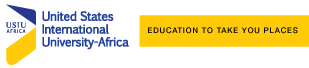

#APT3025 –Applied Machine Learning
#Topic: Practical: Clustering
#**Lecturer:** Dr. Peter Juma

# New section
# WEEK 8: Practical: Clustering
# **Learning Outcomes**

By the end of this course, students will be able to:

1.	Define unsupervised learning
2.	Explain association rule learning and clustering
3.	Implement basic algorithms
4.	Analyze and interpret results


# **Implementation of K-Means Clustering**

We will be using blobs datasets and show how clusters are made using Python programming language.

**Step 1: Importing the necessary libraries**

We will be importing the following libraries.

* **Numpy:** for numerical operations (e.g., distance calculation).
* **Matplotlib:** for plotting data and results.
* **Scikit learn:** to create a synthetic dataset using make_blobs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

ModuleNotFoundError: No module named 'matplotlib.colorbar'

**Step 2: Creating Custom Dataset**

We will generate a synthetic dataset with make_blobs.

* **make_blobs(n_samples=500, n_features=2, centers=3):** Generates 500 data points in a 2D space, grouped into 3 clusters.
* **plt.scatter(X[:, 0], X[:, 1]):** Plots the dataset in 2D, showing all the points.
* **plt.show():** Displays the plot

In [ ]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

**Step 3: Initializing Random Centroids**

We will randomly initialize the centroids for K-Means clustering

* **np.random.seed(23):** Ensures reproducibility by fixing the random seed.
* The for loop initializes k random centroids, with values between -2 and 2, for a 2D dataset.

In [ ]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }

    clusters[idx] = cluster

clusters

**Step 4: Plotting Random Initialized Center with Data Points**

We will now plot the data points and the initial centroids.

* **plt.grid():** Plots a grid.

* **plt.scatter(center[0], center[1], marker='*', c='red'):** Plots the cluster center as a red star (* marker).

In [ ]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

**Step 5: Defining Euclidean Distance**

To assign data points to the nearest centroid, we define a distance function:

* **np.sqrt():** Computes the square root of a number or array element-wise.
* **np.sum():** Sums all elements in an array or along a specified axis

In [ ]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

**Step 6: Creating Assign and Update Functions**

Next, we define functions to assign points to the nearest centroid and update the centroids based on the average of the points assigned to each cluster.

* **dist.append(dis):** Appends the calculated distance to the list dist.
* **curr_cluster = np.argmin(dist):**  Finds the index of the closest cluster by selecting the minimum distance.
* **new_center = points.mean(axis=0):** Calculates the new centroid by taking the mean of the points in the cluster.

In [ ]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []

        curr_x = X[idx]

        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center

            clusters[i]['points'] = []
    return clusters

**Step 7: Predicting the Cluster for the Data Points**

We create a function to predict the cluster for each data point based on the final centroids.

* **pred.append(np.argmin(dist)):** Appends the index of the closest cluster (the one with the minimum distance) to pred.

In [ ]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

**Step 8: Assigning, Updating and Predicting the Cluster Centers**

We assign points to clusters, update the centroids and predict the final cluster labels.

* **assign_clusters(X, clusters):** Assigns data points to the nearest centroids.
* **update_clusters(X, clusters):** Recalculates the centroids.
* **pred_cluster(X, clusters):** Predicts the final clusters for all data points.

In [ ]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

**Step 9: Plotting Data Points with Predicted Cluster Centers**

Finally, we plot the data points, colored by their predicted clusters, along with the updated centroids.

* **center = clusters[i]['center']:** Retrieves the center (centroid) of the current cluster.
* **plt.scatter(center[0], center[1], marker='^', c='red'):**  Plots the cluster center as a red triangle (^ marker).

In [ ]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

# **Implementation of DBSCAN Algorithm**

Here we’ll use the Python library sklearn to compute DBSCAN and matplotlib.pyplot library for visualizing clusters.

**Step 1: Importing Libraries**

We import all the necessary library like numpy , matplotlib and scikit-learn.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import rand_score, adjusted_rand_score
from sklearn import datasets

**Step 2: Preparing Dataset**

We will create a dataset of 4 clusters using **make_blob**.

The dataset have 300 points that are grouped into 4 visible clusters.

In [ ]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.50, random_state=0)

**Step 3: Applying DBSCAN Clustering**

Now we apply DBSCAN clustering on our data, count it and visualize it using the matplotlib library.

* **eps=0.3:** The radius to look for neighboring points.
* **min_samples:** Minimum number of points required to form a dense region a cluster.
* **labels:** Cluster numbers for each point. -1 means the point is considered noise.

In [ ]:
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:

        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

As shown in above output image cluster are shown in different colours like yellow, blue, green and red.

**Step 4: Evaluation Metrics For DBSCAN Algorithm In Machine Learning**


We will use the **Silhouette score** and **Adjusted rand score** for evaluating clustering algorithms.

* **Silhouette's score**  is in the range of -1 to 1. A score near 1 denotes the best meaning that the data point i is very compact within the cluster to which it belongs and far away from the other clusters. The worst value is -1. Values near 0 denote overlapping clusters.

* Absolute Rand Score is in the range of 0 to 1. More than 0.9 denotes excellent cluster recovery and above 0.8 is a good recovery. Less than 0.5 is considered to be poor recovery.

In [ ]:
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

# **OPTICS Clustering - ML**


OPTICS (Ordering Points To Identify the Clustering Structure) is a density-based clustering algorithm similar to DBSCAN clustering. Unlike DBSCAN which struggles with varying densities. OPTICS does not directly assign clusters but instead creates a reachability plot which visually represents clusters. The key concepts in OPTICS are:

* **Core Distance:** The minimum distance needed for a point to be classified as a core point. If a point does not have enough nearby neighbours, its core distance is undefined.

* **Reachability Distance:**  It is a measure of how difficult it is to reach from one point to another. It is calculated as the larger core distance of the starting point and the actual point.

Epsilon (Eps) = 6mm and MinPts = 5.
The core distance of point p is 3mm meaning it needs at least 5 points within a 3mm radius to be considered as a core point.
The reachability distance from q to p is 7mm (since q is farther than p's core distance).
The reachability distance from r to p is 3mm (since r is within p's core distance).
It is more informative than DBSCAN as the reachability plot provides better understanding of clustering structure. Now we will learn about its working.

**Working of OPTICS**
1. The algorithm selects a starting point and checks if it has at least MinPts neighbors within Eps.
2. If the point meets the density requirement it is marked as a core point and nearby points are then analyzed.
3. Reachability distance is computed for each neighboring point.
4. Points are then processed in order of their reachability distance hence forming a reachability plot.
5. Clusters appear as valleys i.e low reachability distances and noise appears as peaks i.e high reachability distances.


# **Implementing OPTICS**
Below is the Python implementation using scikit-learn to demonstrate OPTICS on a synthetic dataset of varying densities:

* **OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05):**  Configures the OPTICS algorithm.

* **labels=clustering.labels_:**  Retrieves cluster labels.
plt.scatter(): Plots the clustering results.

In [ ]:
from sklearn.cluster import OPTICS
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

clustering = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
clustering.fit(X)

labels = clustering.labels_

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', edgecolor='k')
plt.title("OPTICS Clustering on Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()